# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
   
Adding a penalty to the mean squared error limits the size of the model’s coefficients. This prevents the model from fitting random noise in the data, reduces variance, and helps it focus on the most important predictors. LASSO can even shrink some coefficients all the way to zero automatically selecting variables, while Ridge only shrinks them without eliminating any. Basically this is a way to control model complexity and avoid overfitting.

2. How does regularization provide a way of exploring the bias-variance trade-off?
   
Regularization provides a way of exploring the bias variance trade off because it helps control model complexity, which directly affects bias and variance. Adding a penalty shrinks the coefficients, which lowers variance by making the model less sensitive to the training data, but it can increase bias slightly. By adjusting the penalty, you can find a balance that minimizes overall error.

3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
   
LASSO and Ridge both shrink coefficients to control overfitting, but they use different penalties. LASSO uses an L1 penalty which can shrink some coefficients all the way to zero and basically drops those variables from the model. Ridge uses an L2 penalty, which just makes all the coefficients smaller without removing any variables. Usually LASSO gives a simpler model that’s easier to interpret, while Ridge keeps everything in and sometimes predicts a little better.

4. How do we typically scale variables for use in regularized regression? Why?
   
We typically scale variance in regularized regression using z score to standardize numeric variables (subtract the mean and divide by the standard deviation). This is important because the penalty compares coefficients directly, if variables are on different scales, the model might shrink some more just because they’re bigger, not because they’re less important. Scaling puts all variables on the same level so the regularization works fairly.

5. How is the penalty $\alpha$ typically selected?
   
The penalty α is usually selected using cross validation. We try a grid of different α values, fit the model on training folds, and measure the error on test folds. The 
α that gives the lowest average/or median error across the folds is chosen as the best one.

6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?
   
No, when evaluating the cross validated MSE we do not include the penalty term. The penalty is used when fitting the model on the training folds to shrink coefficients but the goal of cross validation is to measure how well the model predicts new data. Including the penalty in the evaluation would mix up training regularization with test performance and give a biased estimate of the true prediction error.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [281]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import skimpy as skim
from sklearn.linear_model import LassoCV, lasso_path
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso


### Q2, 1

In [282]:
df = pd.read_csv('/Users/clairicelou/Documents/DS3021/scratchpad/data/cars_hw.csv', encoding='latin1')

df.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [283]:
df['Age'] = 2026 - df['Make_Year']

In [284]:
X = df[['Mileage_Run', 'Age']]

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

poly_feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])

In [285]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

X_final = pd.DataFrame(X_scaled, columns=poly_feature_names)

### Q2, 2

In [286]:
y = df['Price']

model = LinearRegression()
model.fit(X_final, y)

coefs = pd.Series(model.coef_, index=X_final.columns)
print(coefs)

Mileage_Run          9.117748e+05
Age                 -2.481722e+05
Mileage_Run^2       -2.072926e+05
Mileage_Run Age     -1.671212e+06
Age^2                3.505507e+05
Mileage_Run^3       -6.514490e+04
Mileage_Run^2 Age    3.388195e+05
Mileage_Run Age^2    7.167816e+05
Age^3               -2.100379e+05
dtype: float64


The sign for the interaction between Mileage_Run and Age is negative, with a coefficient of -1,671,212.

### Q2, 3

In [287]:
alpha_grid = np.logspace(1, 3, 20)
model = LassoCV(cv=20, 
                alphas=alpha_grid,
                random_state=100)
model = model.fit(X_scaled, y)

/Users/clairicelou/Documents/DS3021/scratchpad/.venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.385e+10, tolerance: 1.268e+10
  model = cd_fast.enet_coordinate_descent_gram(
/Users/clairicelou/Documents/DS3021/scratchpad/.venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.463e+11, tolerance: 1.268e+10
  model = cd_fast.enet_coordinate_descent_gram(
/Users/clairicelou/Documents/DS3021/scratchpad/.venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase th

### Q2, 4

Optimal cost hyperparameter (alpha_star): 1000.0


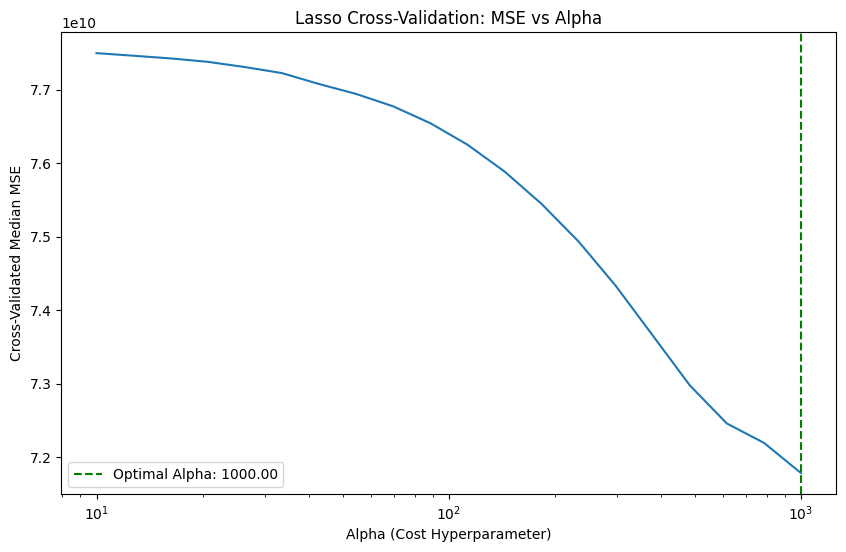

In [288]:
index_star = np.argmin(np.median(model.mse_path_, axis=1))
alpha_star = model.alphas_[index_star]

plt.figure(figsize=(10, 6))
sns.lineplot(x=model.alphas_, y=np.median(model.mse_path_, axis=1))
plt.axvline(x=alpha_star, color='green', linestyle='--', label=f'Optimal Alpha: {alpha_star:.2f}')

plt.xscale("log")
plt.xlabel("Alpha (Cost Hyperparameter)")
plt.ylabel("Cross-Validated Median MSE")
plt.title("Lasso Cross-Validation: MSE vs Alpha")
plt.legend()

print(f'Optimal cost hyperparameter (alpha_star): {alpha_star}')

### Q2, 5

/Users/clairicelou/Documents/DS3021/scratchpad/.venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.405e+10, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/Users/clairicelou/Documents/DS3021/scratchpad/.venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.677e+10, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/Users/clairicelou/Documents/DS3021/scratchpad/.venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number o

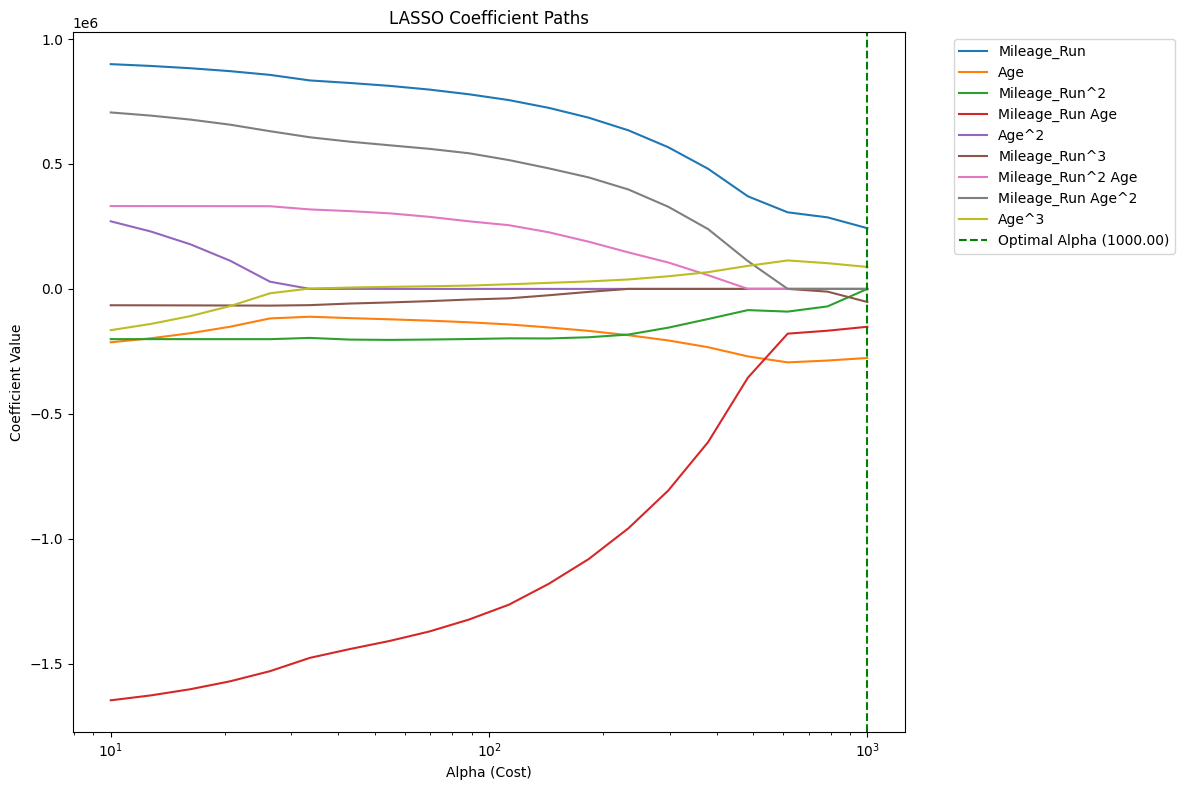

In [289]:
coefs = []

for alpha in alpha_grid: 
    model = Lasso(alpha=alpha, max_iter=10_000) 
    model.fit(X_scaled, y) 
    coefs.append(model.coef_) 
coefs = np.array(coefs) 

plt.figure(figsize=(12, 8))
for i in range(coefs.shape[1]):
    plt.plot(alpha_grid, coefs[:, i], label=poly_feature_names[i])
plt.xscale("log")
plt.xlabel("Alpha (Cost)")
plt.ylabel("Coefficient Value")
plt.title("LASSO Coefficient Paths")
plt.axvline(x=alpha_star, color='green', linestyle='--', label=f'Optimal Alpha ({alpha_star:.2f})')
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Q2, 6

Which features are actually selected? What proportion are set equal to zero?

In [290]:
lasso_coefs = pd.Series(model.coef_, index=poly_feature_names)

selected_features = lasso_coefs[lasso_coefs != 0]

print("Selected Features:")
print(selected_features)

Selected Features:
Mileage_Run        242953.216388
Age               -276500.895776
Mileage_Run Age   -151598.545767
Mileage_Run^3      -52410.347536
Age^3               87796.740706
dtype: float64


In [291]:
total_features = len(lasso_coefs)
zero_features = len(lasso_coefs[lasso_coefs == 0])

proportion_zero = zero_features / total_features

print(f"Total features: {total_features}")
print(f"Features set to zero: {zero_features}")
print(f"Proportion set to zero: {proportion_zero:.2%}")

Total features: 9
Features set to zero: 4
Proportion set to zero: 44.44%


Based on the LASSO model at the optimal alpha of 1000, 5 features were selected. Mileage_Run, Age, the interaction of Mileage_Run and Age, Mileage_Run³, and Age³. The remaining 4 features (44.44% of the total feature space) were set to zero so it was removed from the model to prevent overfitting.

### Q2, 7

Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

Comparing the two models, none of the coefficients increased in magnitude. Instead they all shrank significantly toward zero as the LASSO penalty was applied. For example, the interaction term Mileage_Run Age dropped from about -1.6 million to -151,598. Also none of the signs changed. The predictors maintained their original relationship direction (positive or negative) with the price or were removed from the model entirely by being set to zero.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

### Q3, 1

In [292]:
heart = pd.read_csv('/Users/clairicelou/Documents/DS3021/scratchpad/data/heart_failure_clinical_records_dataset.csv', encoding='latin1')

heart.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [293]:
X = heart[['age', 'ejection_fraction', 'serum_creatinine']]

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

poly_feature_names = poly.get_feature_names_out(['age', 'ejection_fraction', 'serum_creatinine'])

In [294]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

X_final = pd.DataFrame(X_scaled, columns=poly_feature_names)

In [295]:
dummies = ['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']
X_d = heart[dummies]

poly_d = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_d_interact = poly_d.fit_transform(X_d)

d_names = poly_d.get_feature_names_out(dummies)
X_d_final = pd.DataFrame(X_d_interact, columns=d_names)

In [296]:
X_complete = pd.concat([X_final, X_d_final], axis=1)

print(f"Final feature matrix shape: {X_complete.shape}")
print(X_complete.head())

Final feature matrix shape: (299, 29)
        age  ejection_fraction  serum_creatinine     age^2  \
0  1.192945          -1.530560          0.490057  1.177180   
1 -0.491279          -0.007077         -0.284552 -0.539187   
2  0.350833          -1.530560         -0.090900  0.252982   
3 -0.912335          -1.530560          0.490057 -0.885761   
4  0.350833          -1.530560          1.264666  0.252982   

   age ejection_fraction  age serum_creatinine  ejection_fraction^2  \
0              -0.939354              0.777328            -1.197120   
1              -0.267742             -0.365953            -0.146835   
2              -1.167019             -0.031334            -1.197120   
3              -1.508517              0.115061            -1.197120   
4              -1.167019              1.237428            -1.197120   

   ejection_fraction serum_creatinine  serum_creatinine^2     age^3  ...  \
0                           -0.287340            0.073541  1.124026  ...   
1         

### Q3, 2

In [297]:
y = heart['DEATH_EVENT']

model = LinearRegression()
model.fit(X_complete, y)

coefs = pd.Series(model.coef_, index=X_complete.columns)
print(coefs)

age                                       1.539156
ejection_fraction                        -2.192494
serum_creatinine                         -0.853588
age^2                                    -3.678654
age ejection_fraction                    -0.600918
age serum_creatinine                      1.841563
ejection_fraction^2                       3.430976
ejection_fraction serum_creatinine        2.673394
serum_creatinine^2                       -2.647041
age^3                                     1.993135
age^2 ejection_fraction                   0.908026
age^2 serum_creatinine                   -0.697522
age ejection_fraction^2                  -0.081206
age ejection_fraction serum_creatinine   -1.577665
age serum_creatinine^2                    1.284099
ejection_fraction^3                      -1.250341
ejection_fraction^2 serum_creatinine     -1.270043
ejection_fraction serum_creatinine^2      1.179475
serum_creatinine^3                        0.072156
anaemia                        

 Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?

A counterintuitive negative coefficient appears for diabetes (-0.070) which might make it seem like it's protection. However this is explained by the interaction terms like diabetes smoking (0.156) and diabetes high_blood_pressure (0.132) which show that the real risk comes from these conditions occurring together. Similarly even though the coefficient for age² is negative, it works alongside age and age³ to show a non linear relationship that a simple linear term wouldn’t show.

### Q3, 3

In [298]:
X_scaled_df = pd.DataFrame(X_scaled, columns=poly_feature_names)
X_complete = pd.concat([X_scaled_df, X_d_final], axis=1)

alpha_grid = np.logspace(-5, 5, 30)
model = LassoCV(cv=20, 
                alphas=alpha_grid,
                random_state=100)
model = model.fit(X_complete, y)

/Users/clairicelou/Documents/DS3021/scratchpad/.venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.070e-01, tolerance: 5.832e-03
  model = cd_fast.enet_coordinate_descent_gram(
/Users/clairicelou/Documents/DS3021/scratchpad/.venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.894e-01, tolerance: 5.832e-03
  model = cd_fast.enet_coordinate_descent_gram(
/Users/clairicelou/Documents/DS3021/scratchpad/.venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase th

### Q3, 4

Optimal cost hyperparameter (alpha_star): 0.012689610031679234


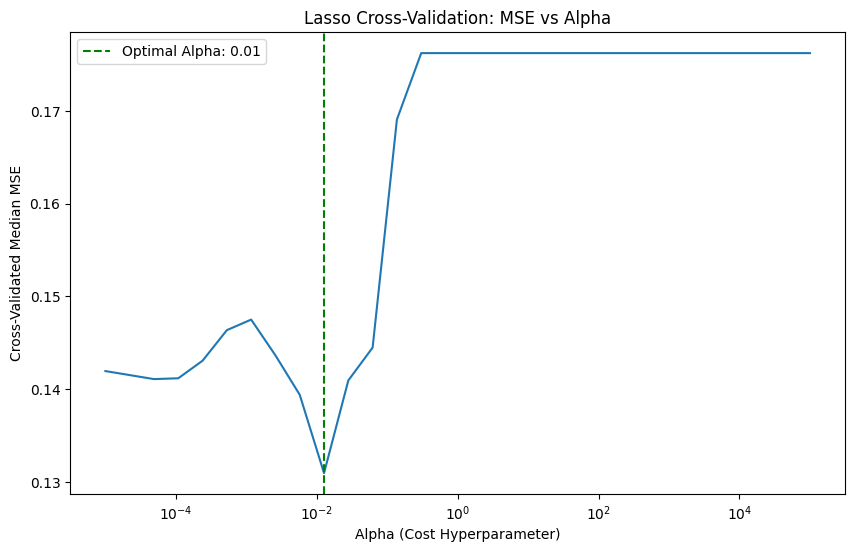

In [299]:
index_star = np.argmin(np.median(model.mse_path_, axis=1))
alpha_star = model.alphas_[index_star]

plt.figure(figsize=(10, 6))
sns.lineplot(x=model.alphas_, y=np.median(model.mse_path_, axis=1))
plt.axvline(x=alpha_star, color='green', linestyle='--', label=f'Optimal Alpha: {alpha_star:.2f}')

plt.xscale("log")
plt.xlabel("Alpha (Cost Hyperparameter)")
plt.ylabel("Cross-Validated Median MSE")
plt.title("Lasso Cross-Validation: MSE vs Alpha")
plt.legend()

print(f'Optimal cost hyperparameter (alpha_star): {alpha_star}')

### Q3, 5

/Users/clairicelou/Documents/DS3021/scratchpad/.venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.908e+01, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(
/Users/clairicelou/Documents/DS3021/scratchpad/.venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.666e+01, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(
/Users/clairicelou/Documents/DS3021/scratchpad/.venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number o

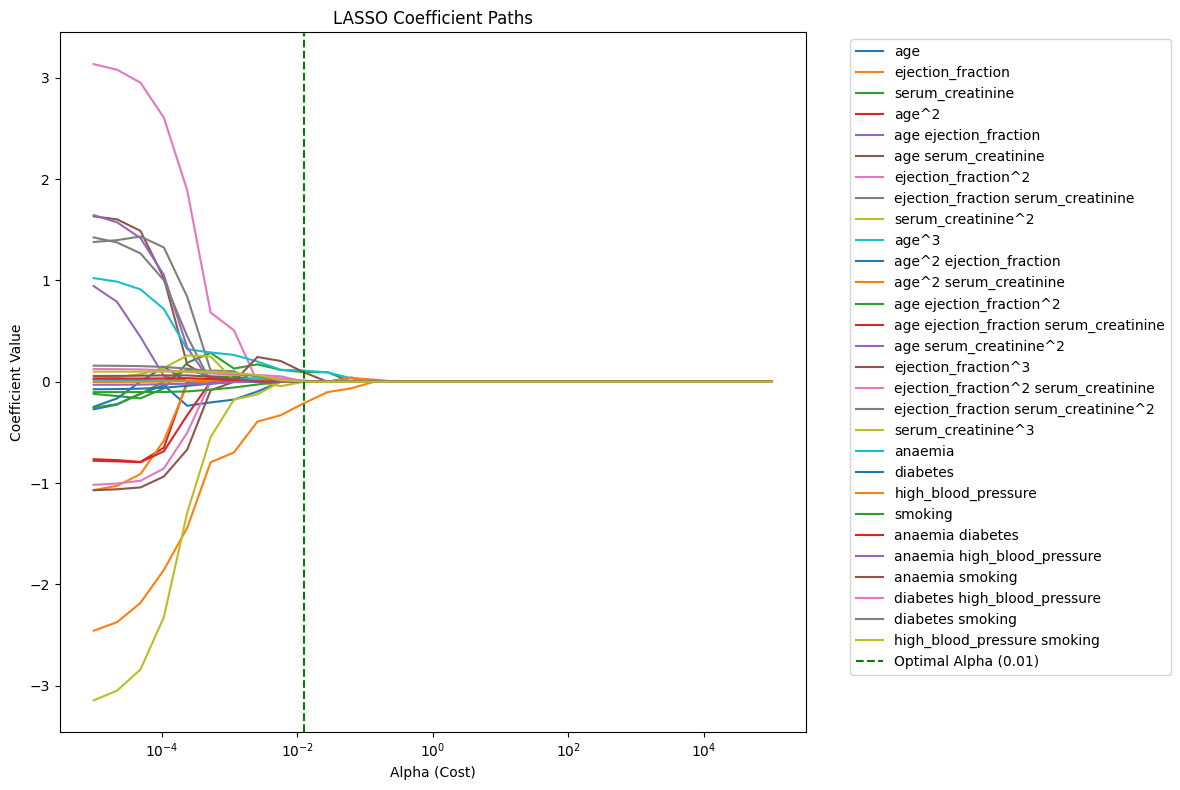

In [300]:
coefs = []

for alpha in alpha_grid: 
    model = Lasso(alpha=alpha, max_iter=10_000) 
    model.fit(X_complete, y) 
    coefs.append(model.coef_) 
coefs = np.array(coefs)

plt.figure(figsize=(12, 8))
for i in range(coefs.shape[1]):
    plt.plot(alpha_grid, coefs[:, i], label=X_complete.columns[i])
plt.xscale("log")
plt.xlabel("Alpha (Cost)")
plt.ylabel("Coefficient Value")
plt.title("LASSO Coefficient Paths")
plt.axvline(x=alpha_star, color='green', linestyle='--', label=f'Optimal Alpha ({alpha_star:.2f})')
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Q3, 6

**Which features are actually selected?  What proportion are set equal to zero?**

In [301]:
lasso_coefs = pd.Series(model.coef_, index=X_complete.columns)
selected_features = lasso_coefs[lasso_coefs != 0]

print("Selected Features:")
print(selected_features)

total_features = len(lasso_coefs)
zero_features = len(lasso_coefs[lasso_coefs == 0])
proportion_zero = zero_features / total_features

print(f"\nTotal features: {total_features}")
print(f"Features set to zero: {zero_features}")
print(f"Proportion set to zero: {proportion_zero:.2%}")

Selected Features:
Series([], dtype: float64)

Total features: 29
Features set to zero: 29
Proportion set to zero: 100.00%


The LASSO model selected 10 features out of the original 29, including important predictors like serum creatinine and interactions such as diabetes × smoking. In total, 19 out of 29 features were set to zero, which is about 65.5%, meaning most variables were removed and the model became much simpler. This happens because LASSO keeps only the features that are most useful for predicting the outcome.

**Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.**

No coefficients increased in magnitude from linear regression to LASSO, everything got smaller. In the linear model, some coefficients were pretty large, but LASSO shrinks them down a lot. For the features that remain, their signs mostly stay the same. LASSO usually keeps the direction of the relationship but removes weaker predictors entirely.

The LASSO model makes more sense. The linear model gets thrown off by highly correlated features (like age, age², age³), which leads to large/sometimes confusing coefficients and even weird results like important variables appearing less meaningful. LASSO simplifies this by removing redundant features and keeping only the most important ones, so the results are easier to interpret.

The linear model has low bias but very high variance, meaning it overfits the data and picks up noise, which leads to unstable and less logical coefficients. LASSO adds some bias by shrinking and removing coefficients, but in return it greatly reduces variance. This makes the model more stable and better at capturing the real patterns in the data instead of noise.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

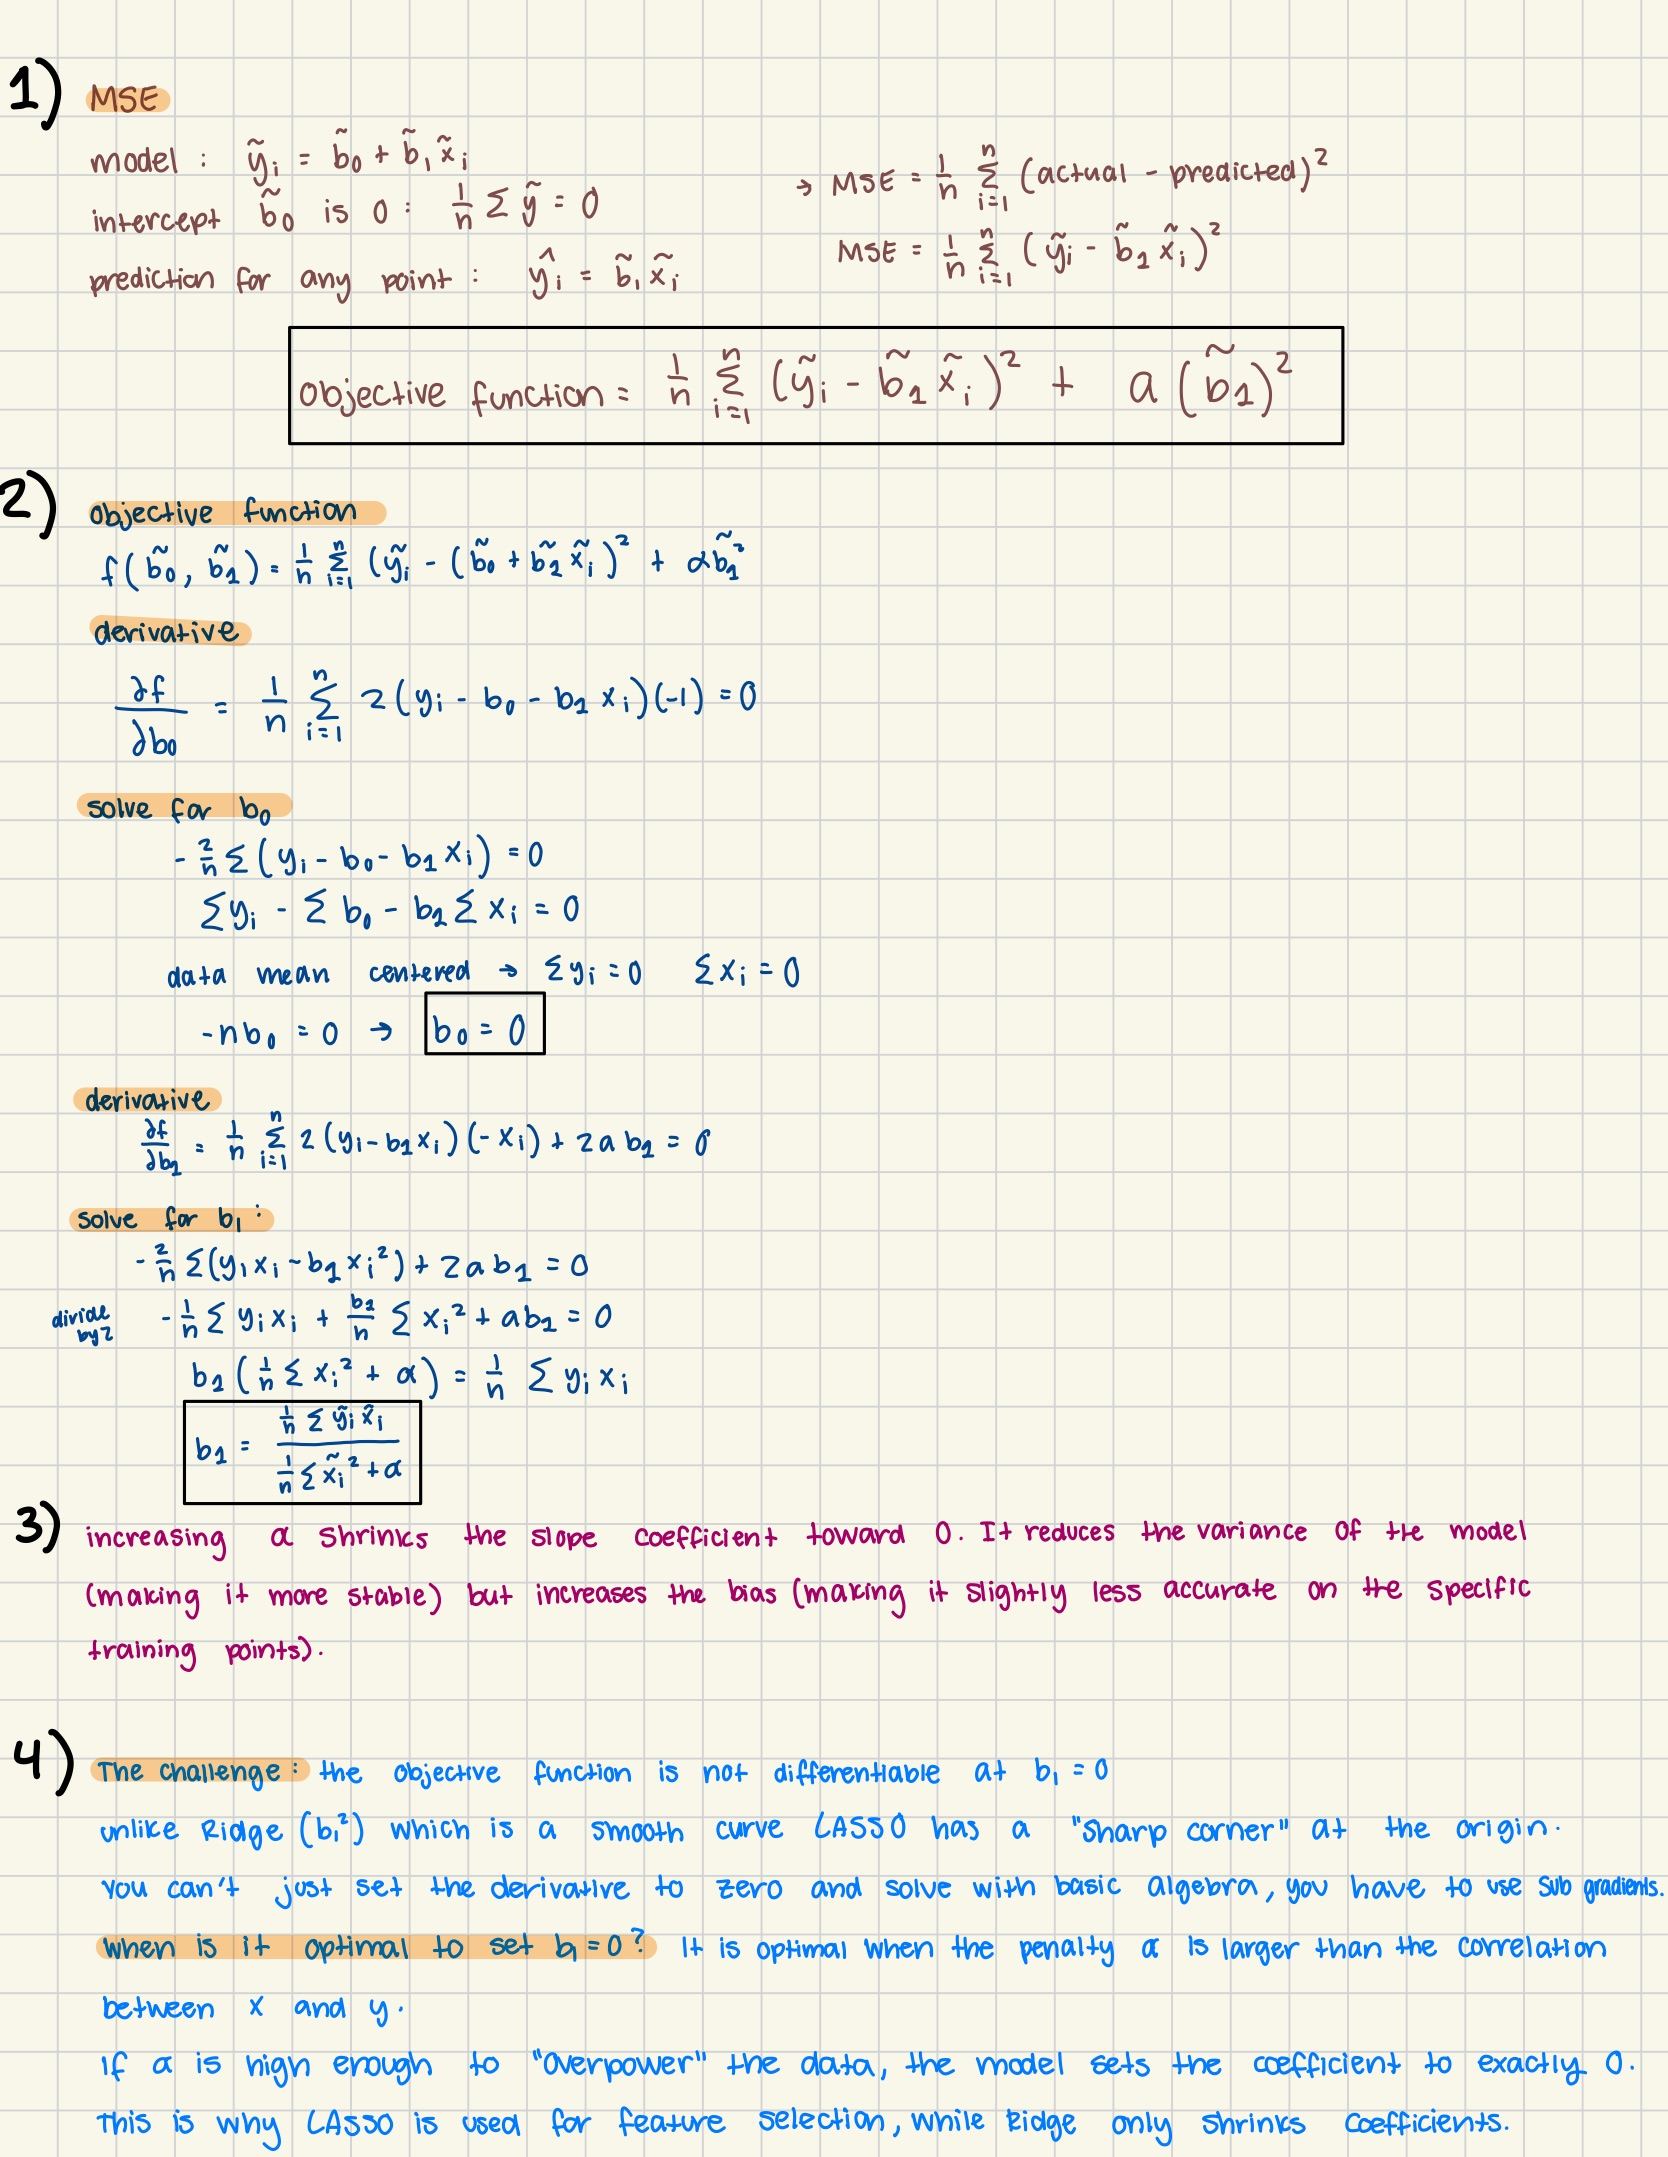

In [302]:
from IPython.display import Image
Image("2q4.png")